# Market risk via EVT + t-copula

**pyportfolios.com** · [/research/evt-t-copula-var](https://pyportfolios.com/research/evt-t-copula-var) · ^GSPC + ^FTSE, 2000 – 2024 · NumPy · Pandas · SciPy · arch · yfinance

The reference conditional tail-risk pipeline (McNeil–Frey), end to end on real data:

1. GARCH(1,1)-t filter per asset → i.i.d.-ish standardised residuals,
2. semi-parametric margins — empirical body, GPD (Pareto) tails beyond the 95% quantile,
3. Student-t copula calibrated by profile MLE,
4. 100,000 seeded Monte-Carlo scenarios → portfolio VaR/CVaR on a 60/40 S&P/FTSE book,
   compared against conditional Gaussian and unconditional historical VaR.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model                      # pip install arch
from scipy.special import gammaln
from scipy.stats import genpareto, norm, rankdata, t as student_t, chi2

plt.rcParams["figure.figsize"] = (10, 5)
SEED, Q, N_SIM = 42, 0.95, 100_000
weights = np.array([0.6, 0.4])                   # ^GSPC / ^FTSE

## 1 · Data: 25 years of S&P 500 and FTSE 100

Two developed-market indices with a quarter century of joint history — dot-com,
2008, the euro crisis, COVID, 2022. Log returns on days both markets traded.

In [2]:
px = yf.download(["^GSPC", "^FTSE"], start="2000-01-01", end="2025-01-01",
                 auto_adjust=True, progress=False)["Close"].dropna()
rets = np.log(px / px.shift(1)).dropna()[["^GSPC", "^FTSE"]]
cols = list(rets.columns)
print(f"{len(rets)} joint trading days, {rets.index[0].date()} -> {rets.index[-1].date()}")

6171 joint trading days, 2000-01-05 -> 2024-12-31


## 2 · GARCH-t volatility filtering

Fit an AR(0)–GARCH(1,1) with Student-t innovations per asset; keep the
standardised residuals $z = \varepsilon/\hat\sigma$ (close to i.i.d.) and the
one-day-ahead volatility forecast (this is what makes the VaR *conditional*).

In [3]:
Z, sigma_f = {}, {}
for c in cols:
    res = arch_model(100 * rets[c], mean="Constant",
                     vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
    Z[c] = res.std_resid
    sigma_f[c] = float(np.sqrt(res.forecast(horizon=1).variance.iloc[-1, 0]))
    print(f"{c}: alpha+beta = {res.params['alpha[1]'] + res.params['beta[1]']:.3f}   "
          f"nu = {res.params['nu']:.1f}   sigma_fcast = {sigma_f[c] / 100:.4%}/day")
Z = pd.DataFrame(Z).dropna()

^GSPC: alpha+beta = 0.997   nu = 6.3   sigma_fcast = 1.0669%/day


^FTSE: alpha+beta = 0.986   nu = 7.7   sigma_fcast = 0.6220%/day


## 3 · Semi-parametric margins: empirical body, Pareto tails

Peaks-over-threshold: beyond the 95% quantile of each residual series,
fit a Generalised Pareto to the exceedances. A positive shape ξ is a genuine
power-law tail. The QQ plot against the fitted GPD is the honesty check.

^GSPC loss tail: u = 1.752   xi = 0.039   beta = 0.694
^FTSE loss tail: u = 1.777   xi = 0.010   beta = 0.602


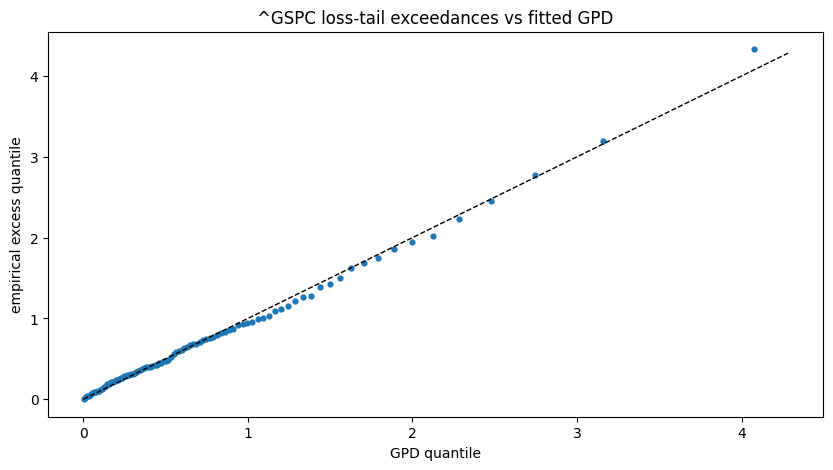

In [4]:
def fit_pot(z, q=Q):
    u = float(np.quantile(z, q))
    xi, _, beta = genpareto.fit(z[z > u] - u, floc=0)
    return u, float(xi), float(beta)

tails = {c: {"upper": fit_pot(Z[c].values),
             "lower": fit_pot(-Z[c].values)} for c in cols}   # lower = loss tail
for c in cols:
    u, xi, beta = tails[c]["lower"]
    print(f"{c} loss tail: u = {u:.3f}   xi = {xi:.3f}   beta = {beta:.3f}")

# QQ plot, S&P loss tail
u, xi, beta = tails["^GSPC"]["lower"]
exc = np.sort((-Z["^GSPC"].values)[(-Z["^GSPC"].values) > u] - u)
p = (np.arange(1, 100) - 0.5) / 99
plt.scatter(genpareto.ppf(p, xi, scale=beta), np.quantile(exc, p), s=12)
lim = plt.xlim()[1]
plt.plot([0, lim], [0, lim], "k--", lw=1)
plt.xlabel("GPD quantile"); plt.ylabel("empirical excess quantile")
plt.title("^GSPC loss-tail exceedances vs fitted GPD");

## 4 · Calibrating the t-copula

Rank-transform the residuals to pseudo-uniforms, pin the copula correlation via
Kendall's τ ($\rho = \sin(\pi\tau/2)$, robust to the margins), then profile
the log-likelihood over ν. Low ν = strong tail dependence.

tau = 0.341   rho = 0.511   nu_hat = 8.0


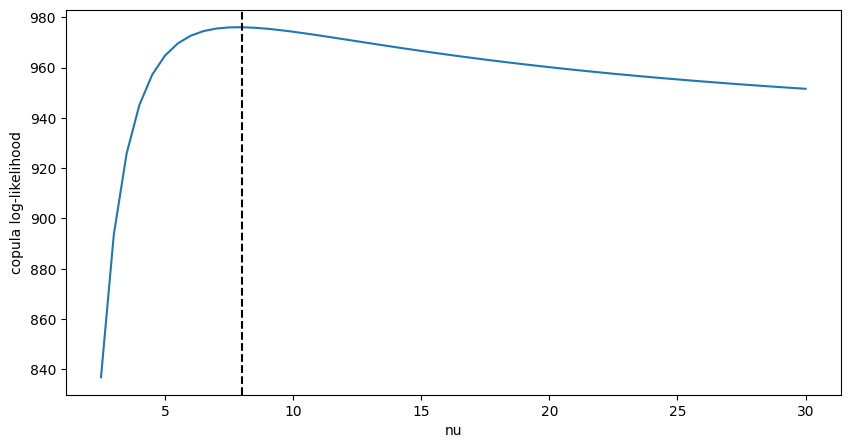

In [5]:
U = Z.apply(lambda s: rankdata(s) / (len(s) + 1)).values
tau = Z[cols[0]].corr(Z[cols[1]], method="kendall")
rho = float(np.sin(np.pi * tau / 2))

def tcopula_loglik(x, rho, nu):
    det = 1 - rho**2
    q = (x[:, 0]**2 - 2*rho*x[:, 0]*x[:, 1] + x[:, 1]**2) / det
    log_mvt = (gammaln((nu + 2)/2) - gammaln(nu/2) - np.log(nu*np.pi)
               - 0.5*np.log(det) - (nu + 2)/2 * np.log1p(q/nu))
    return float((log_mvt - student_t.logpdf(x, nu).sum(axis=1)).sum())

grid = np.arange(2.5, 30.5, 0.5)
lls = [tcopula_loglik(student_t.ppf(U, nu), rho, nu) for nu in grid]
nu_hat = float(grid[int(np.argmax(lls))])
print(f"tau = {tau:.3f}   rho = {rho:.3f}   nu_hat = {nu_hat:.1f}")
plt.plot(grid, lls); plt.axvline(nu_hat, ls="--", c="k")
plt.xlabel("nu"); plt.ylabel("copula log-likelihood");

## 5 · Monte Carlo: joint scenarios with the right tails

Sample the t-copula (Gaussian draw × common χ² mixing — the shared shock is
exactly what creates joint crashes), invert the semi-parametric margins, and
re-inflate by the GARCH volatility forecasts.

In [6]:
rng = np.random.default_rng(SEED)
L = np.linalg.cholesky(np.array([[1, rho], [rho, 1]]))
g = (L @ rng.standard_normal((2, N_SIM))).T
mix = np.sqrt(nu_hat / chi2.rvs(nu_hat, size=(N_SIM, 1), random_state=rng))
U_sim = student_t.cdf(g * mix, df=nu_hat)

def inv_margin(u, z, lo, hi, q=Q):
    out = np.quantile(z, u)                      # empirical body
    up = u > q
    out[up] = hi[0] + genpareto.ppf((u[up] - q) / (1 - q), hi[1], scale=hi[2])
    dn = u < 1 - q
    out[dn] = -(lo[0] + genpareto.ppf((1 - q - u[dn]) / (1 - q), lo[1], scale=lo[2]))
    return out

sim = np.column_stack([inv_margin(U_sim[:, k], Z[c].values,
                                  tails[c]["lower"], tails[c]["upper"])
                       for k, c in enumerate(cols)])
sf = np.array([sigma_f[c] for c in cols]) / 100
pnl = (sim * sf) @ weights
loss = -pnl

## 6 · Portfolio VaR & CVaR — three answers to one question

EVT + t-copula (simulation), conditional Gaussian (variance–covariance on the
same volatility forecasts), and unconditional historical simulation.

 level  historical  gaussian  t-copula  EVT CVaR
   95%      1.661%    1.310%    1.410%    1.961%
   99%      3.059%    1.853%    2.287%    2.879%


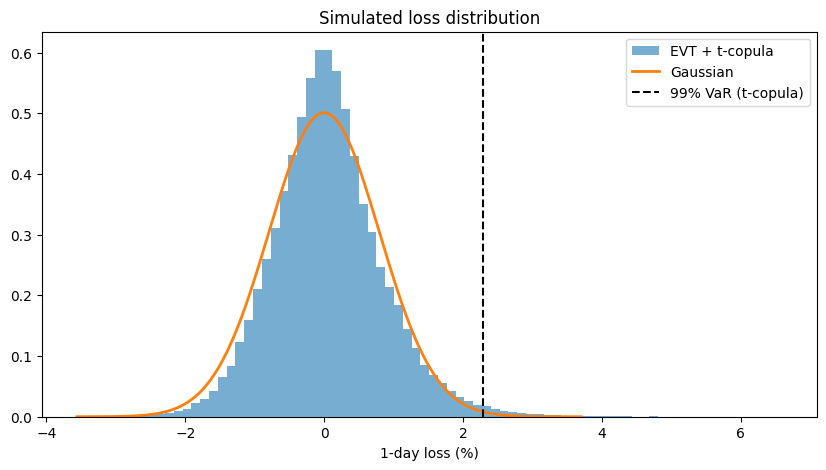

In [7]:
rho_p = Z[cols[0]].corr(Z[cols[1]])
sigma_p = float(np.sqrt(weights @ (np.outer(sf, sf)
                * np.array([[1, rho_p], [rho_p, 1]])) @ weights))
hist_pnl = (rets @ weights).values

print(f"{'level':>6} {'historical':>11} {'gaussian':>9} {'t-copula':>9} {'EVT CVaR':>9}")
for a in (0.95, 0.99):
    v = np.quantile(loss, a)
    cv = loss[loss >= v].mean()
    gauss = -norm.ppf(1 - a) * sigma_p
    hist = -np.quantile(hist_pnl, 1 - a)
    print(f"{a:>6.0%} {hist:>11.3%} {gauss:>9.3%} {v:>9.3%} {cv:>9.3%}")

plt.hist(100 * loss, bins=80, density=True, alpha=0.6, label="EVT + t-copula")
x = np.linspace(100 * loss.min(), 100 * np.percentile(loss, 99.9), 400)
plt.plot(x, norm.pdf(x, 0, 100 * sigma_p), lw=2, label="Gaussian")
plt.axvline(100 * np.quantile(loss, 0.99), ls="--", c="k", label="99% VaR (t-copula)")
plt.xlabel("1-day loss (%)"); plt.legend(); plt.title("Simulated loss distribution");

## Takeaways

- GARCH filtering first (McNeil–Frey) makes everything downstream conditional —
  the VaR tracks today's volatility regime, not a 25-year average.
- Both loss tails fit GPDs with positive shape ξ: genuine power-law tails that a
  normal distribution flatly denies.
- The profiled copula ν is small — strong tail dependence; a Gaussian copula
  (ν → ∞) would assume the two markets decouple exactly when they crash together.
- At 99% the EVT + t-copula VaR sits well above the Gaussian answer on the same
  volatility forecasts; the gap *is* the fat-tail premium.
- All of it is seeded (42) and reproducible; stress the threshold q and the
  ν grid before trusting any of it with capital.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*